Shape of the embeddings: (6355, 1024)
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 6355 samples in 0.004s...


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 6355 samples in 4.262s...
[t-SNE] Computed conditional probabilities for sample 1000 / 6355
[t-SNE] Computed conditional probabilities for sample 2000 / 6355
[t-SNE] Computed conditional probabilities for sample 3000 / 6355
[t-SNE] Computed conditional probabilities for sample 4000 / 6355
[t-SNE] Computed conditional probabilities for sample 5000 / 6355
[t-SNE] Computed conditional probabilities for sample 6000 / 6355
[t-SNE] Computed conditional probabilities for sample 6355 / 6355
[t-SNE] Mean sigma: 7.462889
[t-SNE] KL divergence after 250 iterations with early exaggeration: 69.881607
[t-SNE] KL divergence after 3000 iterations: 0.715193


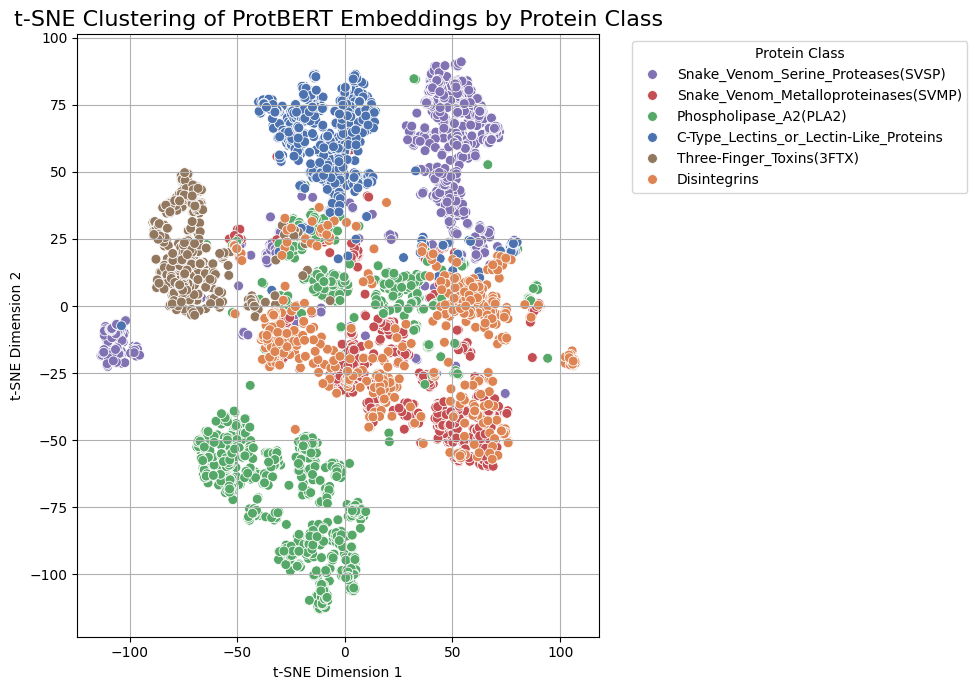

Shape of the embeddings: (1934, 1024)
[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 1934 samples in 0.002s...


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 1934 samples in 0.400s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1934
[t-SNE] Computed conditional probabilities for sample 1934 / 1934
[t-SNE] Mean sigma: 8.235773
[t-SNE] KL divergence after 250 iterations with early exaggeration: 70.919945
[t-SNE] KL divergence after 1000 iterations: 0.856979


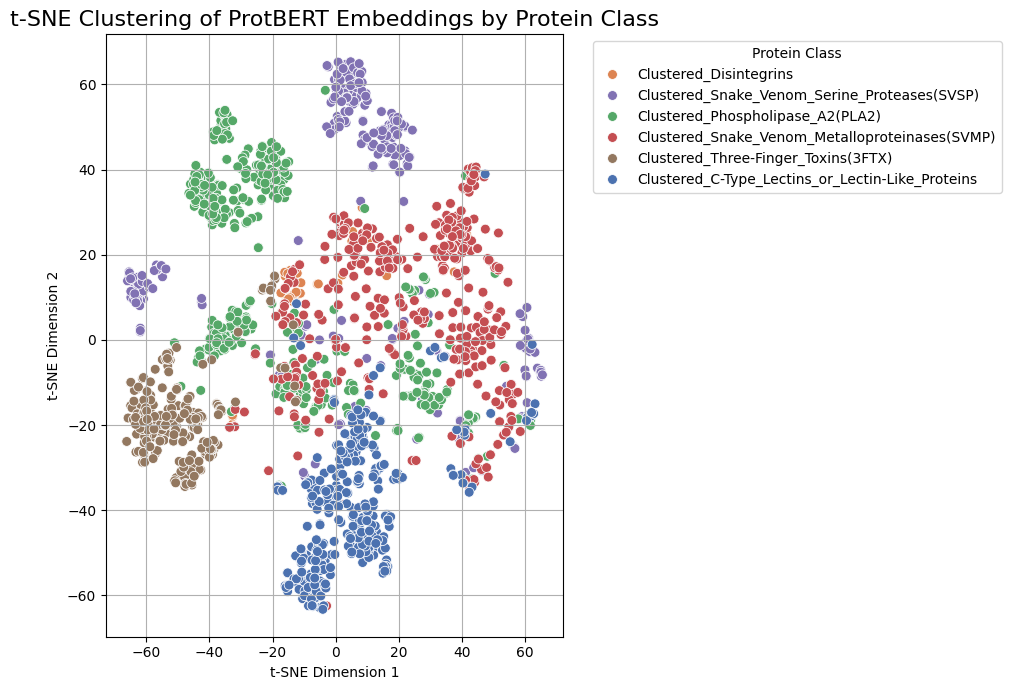

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import pandas as pd

def tsne_clustering(metadata_path, embeddings_path, output_path, perplexity, n_iter):
  # Load the embeddings file
  embeddings = np.load(embeddings_path)
  print("Shape of the embeddings:", embeddings.shape)

  # Load the CSV file with protein class metadata
  metadata = pd.read_csv(metadata_path)
  protein_classes = metadata['protein'].values

  # Define a fixed color mapping for the 6 protein classes
  unique_classes = sorted(metadata['protein'].unique())
  palette = sns.color_palette('deep', n_colors=len(unique_classes))
  color_map = dict(zip(unique_classes, palette))

  # Verify that the number of samples matches
  assert len(protein_classes) == embeddings.shape[0], "Number of samples in embeddings and metadata must match"

  # Scale the embeddings
  scaler = StandardScaler()
  scaled_embeddings = scaler.fit_transform(embeddings)

  # Apply t-SNE
  tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, n_iter=n_iter, verbose=1)
  tsne_results = tsne.fit_transform(scaled_embeddings)

  # Create a scatter plot with colors based on protein classes
  plt.figure(figsize=(10, 7))
  sns.scatterplot(x=tsne_results[:, 0], y=tsne_results[:, 1], hue=protein_classes, palette=color_map, s=50)
  plt.title("t-SNE Clustering of ProtBERT Embeddings by Protein Class", fontsize=16)
  plt.xlabel("t-SNE Dimension 1")
  plt.ylabel("t-SNE Dimension 2")
  plt.grid(True)
  plt.legend(title='Protein Class', bbox_to_anchor=(1.05, 1), loc='upper left')

  # Save the plot
  plt.tight_layout()
  plt.savefig(output_path, dpi=300, bbox_inches='tight')
  plt.show()

metadata_path = "metadata.csv"
embeddings_path = "protbert_embeddings.npy"
output_path = "tsne_protbert_embeddings.png"

tsne_clustering(metadata_path, embeddings_path, output_path, perplexity=40, n_iter=3000)

metadata_path = "clustered_metadata.csv"
embeddings_path = "clustered_protbert_embeddings.npy"
output_path = "clustered_tsne_protbert_embeddings.png"

tsne_clustering(metadata_path, embeddings_path, output_path, perplexity=20, n_iter=1000)

